<a href="https://www.kaggle.com/code/swmath/modelo-summit?scriptVersionId=350707149" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Importação do dataset 

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file_path = 'happydata.csv'

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "priyanshusethi/happiness-classification-dataset",
  file_path)

In [3]:
df.rename(columns={'infoavail': 'Disponibilidade de informação', 
                   'housecost': 'Custo da moradia',
                  'schoolquality' : 'Qualidade de ensino',
                  'policetrust' : 'Confiança na polícia',
                  'streetquality' : 'Qualidade das vias',
                  'ëvents' : 'Eventos públicos',
                  'happy': 'Felicidade'}, inplace=True)

,Disponibilidade de informação,Custo da moradia,Qualidade de ensino,Confiança na polícia,Qualidade das vias,Eventos públicos,Felicidade
0,3,3,3,4,2,4,0
1,3,2,3,5,4,3,0
2,5,3,3,3,3,5,1
3,5,4,3,3,3,5,0
4,5,4,3,3,3,5,0



Valores nulos por coluna:
Disponibilidade de informação    0
Custo da moradia                 0
Qualidade de ensino              0
Confiança na polícia             0
Qualidade das vias               0
Eventos públicos                 0
Felicidade                       0
dtype: int64


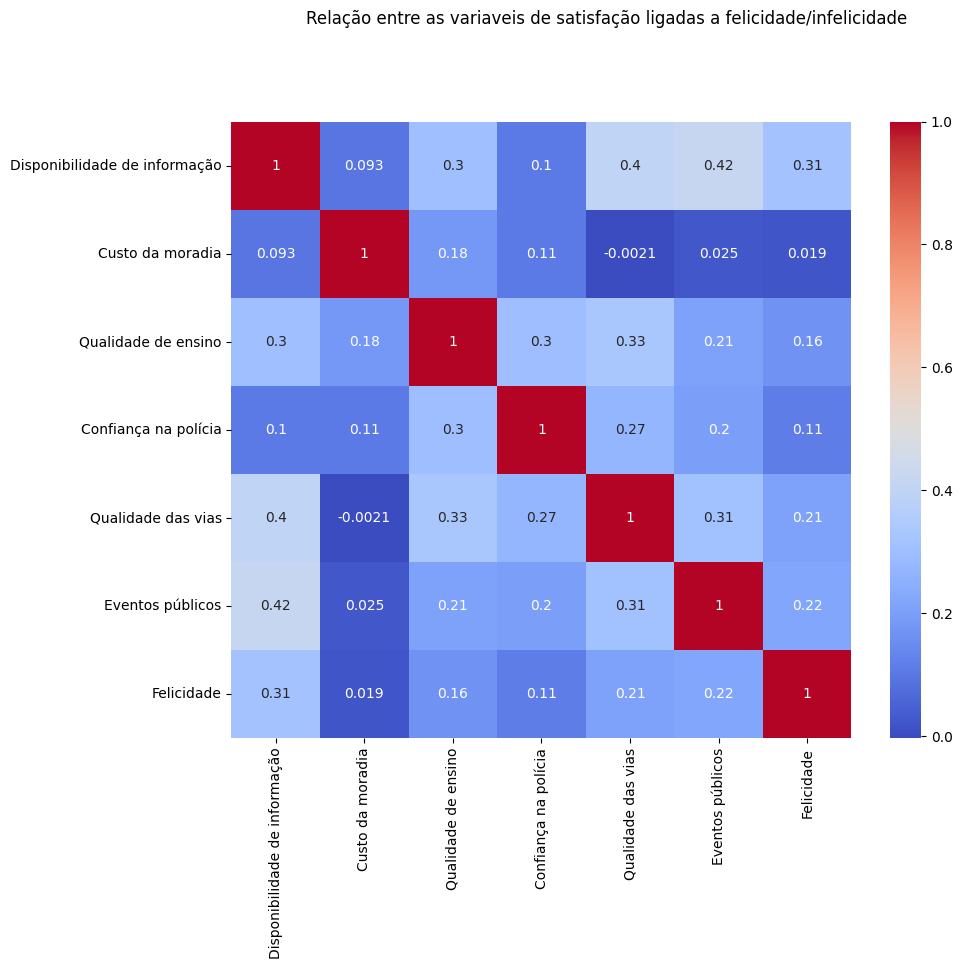

In [4]:
#Mostra as primeiras linhas da tabela
display(df.head())


# Verificação de valores nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())

#Visualização principal: Relação entre as variáveis
#O pairplot cria gráficos de dispersão para todas as combinações de features
plt.figure(figsize=(10, 8))
#sns.pairplot(df, hue='happy', markers=["o", "s"])
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.suptitle("Relação entre as variaveis de satisfação ligadas a felicidade/infelicidade", y=1.02)
plt.show()

# Treinamento do modelo

In [5]:
# Bibliotecas para Machine Learning
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
# Features
X = df.drop(columns = ['Felicidade'])
y = df['Felicidade']  # Os rótulos (labels)

# Dividindo em treino (80%) e teste (20%)
# O stratify=y garante que a proporção de espécies seja igual no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [9]:
# Para achar o melhor treinamento de modelo possível
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}


rf_grid = GridSearchCV(estimator=rf_base, param_grid=rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Melhor acurácia obtida no treino: {rf_grid.best_score_ * 100:.2f}%")
print(f"Melhores parâmetros: {rf_grid.best_params_}")

# Salva o melhor modelo resultado
model = rf_grid.best_estimator_

Melhor acurácia obtida no treino: 61.47%
Melhores parâmetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
importancias = pd.Series(model.feature_importances_, index=X_train.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

print("--- Colunas que mais impactam a Felicidade ---")
print(importancias_ordenadas)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Faz um gráfico Heatmap baseado na matriz 'cm'
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

In [ ]:
df_comparacao = pd.DataFrame({
    'Predito': y_pred,
    'Real': y_test.values  # .values remove o índice para evitar desalinhamento
}, index=y_test.index)

print(df_comparacao)